In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error, recall_score

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"E:\kdt_0900_sal\ml\resource\dataset"
file_name = r"titanic.csv"
file_path = os.path.join(base_path, file_name)

In [3]:
df = pd.read_csv(file_path)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [4]:
titanic_df = df.drop(["PassengerId", "Name", "Ticket", "Cabin", "Embarked"], axis=1)

In [5]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [6]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,male,22.0,1,0,7.2500,2
1,1,1,female,38.0,1,0,71.2833,2
2,1,3,female,26.0,0,0,7.9250,1
3,1,1,female,35.0,1,0,53.1000,2
4,0,3,male,35.0,0,0,8.0500,1


In [8]:
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis=1)

In [9]:
titanic_df.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize
0,0,3,male,22.0,7.2500,2
1,1,1,female,38.0,71.2833,2
2,1,3,female,26.0,7.9250,1
3,1,1,female,35.0,53.1000,2
4,0,3,male,35.0,8.0500,1


In [10]:
titanic_df.shape

(891, 6)

In [11]:
titanic_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
titanic_df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [29]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    int64  
 4   Fare        891 non-null    float64
 5   FamilySize  891 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 41.9 KB


In [14]:
titanic_df["Sex"] = titanic_df["Sex"].astype(str)
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df["Sex"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64

In [15]:
titanic_df.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize
0,0,3,0,22,7.2500,2
1,1,1,1,38,71.2833,2
2,1,3,1,26,7.9250,1
3,1,1,1,35,53.1000,2
4,0,3,0,35,8.0500,1


In [16]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 5) (179, 5) (712,) (179,)


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
lr = LogisticRegression()

In [20]:
# 모델 학습
lr.fit(X_train_scaled, y_train)

# 모델예측
y_pred = lr.predict(X_test_scaled) 

# 모델 평가
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

In [21]:
print(train_score)
print(test_score)

0.8061797752808989
0.7821229050279329


In [22]:
lr2 = LogisticRegression(C=2.0)

In [27]:
# 모델 학습
lr2.fit(X_train_scaled, y_train)

# 모델예측
y_pred2 = lr2.predict(X_test_scaled) 

# 모델 평가
train_score2 = lr2.score(X_train_scaled, y_train)
test_score2 = lr2.score(X_test_scaled, y_test)

In [28]:
print(train_score2)
print(test_score2)

0.7991573033707865
0.7877094972067039


In [25]:
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"정확도: {acc}")
print(f"재현율: {recall}")

정확도: 0.7821229050279329
재현율: 0.7246376811594203


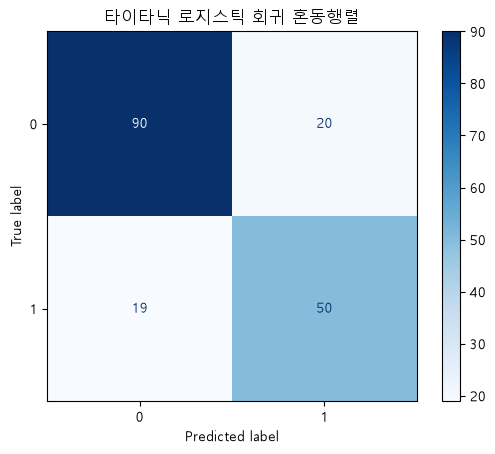

In [26]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()